# Problem Statement
The goal of this notebook is to analyze the budget allocations and actual expenditure of local bodies in Province 1 for FY 2021-22.
I want to identify major spending categories, compare budget vs realized expense at province and local-body levels, and highlight disparities between urban and rural local bodies.

# Objectives
- Load and clean the budget and expenditure data for Province 1.
- Visualize composition of budgets and expenditures (recurrent, capital, financial).
- Measure utilization (expense / budget) at province and local-body levels.
- Identify top and bottom local bodies by spending and discuss possible reasons.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
file_path = "../data/Expenditure-of-local-bodies.xlsx"
if not os.path.exists(file_path):
    print("Dataset not found!")
else:
    print("Good to go!😊")

Good to go!😊


In [3]:
from feature_engineering import FeatureExtraction, FeatureExtractionTotal, FeatureExtractionUrban
from visualization import CompositionAnalysis, PerformanceAnalysis, PieCharts
import pandas as pd

In [4]:
feature_extraction = FeatureExtraction(fname=file_path, province_name="Province 1")
all_content_df = feature_extraction.open_file().copy()
all_content_df_renamed = feature_extraction.rename_label(dataframe=all_content_df).copy()
province1_rows = feature_extraction.extract_rows_for_province(dataframe=all_content_df_renamed).copy()
budget_df_province1 = feature_extraction.extract_budget_frame(dataframe=province1_rows).copy()
expense_df_province1 = feature_extraction.extract_expenditure_frame(dataframe=province1_rows).copy()
budget_df_all = feature_extraction.extract_budget_frame(dataframe=all_content_df_renamed).copy()
expense_df_all = feature_extraction.extract_expenditure_frame(dataframe=all_content_df_renamed)

# ----------------------------------------------------

print("shape of province 1 frame: ", budget_df_province1.shape)
print("Shape of total frame : ", budget_df_all.shape)

budget_df_province1.head()


shape of province 1 frame:  (138, 7)
Shape of total frame :  (767, 7)


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,38.550184,26.144191,0.0,64.694376,7.666711
1,2,Aathrai Tribeni Rural Municipality,26.79269,22.705015,0.0,49.497705,12.857007
2,3,Phaktanglung Rural Municipality,30.862931,15.232376,0.0,46.095307,7.17987
3,4,Mikwakhola Rural Municipality,20.730677,11.014579,0.0,31.745256,6.718961
4,5,Meringdeng Rural Municipality,26.518959,16.155819,0.0,42.674779,2.881517


In [5]:
expense_df_province1.head(8)

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,34.104109,24.514032,0.0,58.61814,7.666711
1,2,Aathrai Tribeni Rural Municipality,21.72991,13.335082,0.0,35.064991,12.857007
2,3,Phaktanglung Rural Municipality,24.071506,12.591538,0.0,36.663044,7.17987
3,4,Mikwakhola Rural Municipality,16.349711,8.581009,0.0,24.93072,6.718961
4,5,Meringdeng Rural Municipality,23.587589,15.188281,0.0,38.775871,2.881517
5,6,Mauwakhola Rural Municipality,18.164198,13.060848,0.0,31.225046,4.327077
6,7,Pathibhara Yangwarak Rural Municipality,23.399494,13.367955,0.0,36.767449,6.686506
7,8,Sidingwa Rural Municipality,24.468454,9.661338,0.0,34.129792,5.39351


In [6]:
feature_extraction_urban = FeatureExtractionUrban(df=budget_df_province1)
budget_df_urban = feature_extraction_urban.extract_urban_features().copy()
budget_df_urban.head()

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
108,109,Biratnagar Metropolitan,174.652121,244.49391,6.0,425.146032,46.12698
125,126,Itahari Sub-Metropolitan,101.885013,108.3975,0.0,210.282513,48.036981
126,127,Dharan Sub-Metropolitan,102.745833,84.668567,2.9477,190.3621,29.887517


```python
feature_extraction_urban.extract_urban_features()
```
Returns the features of  Metropolitan and Sub-Metropolitan local body only.

---
**Observation**: 
- Metropolitan City: 1
- Sub-metropolitan Cities: 2

In [7]:
feature_extraction_urban = FeatureExtractionUrban(df=budget_df_all) # for all 753 local bodies
budget_df_urban_all = feature_extraction_urban.extract_urban_features().copy()
rows, column = budget_df_urban_all.shape
print("Number of rows : ", rows)
budget_df_urban_all.head(rows)

Number of rows :  17


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
385,382,Kathmandu Metropolitan,546.5301,972.5085,37.1128,1556.1514,983.660309
427,422,Pokhara Metropolitan,246.9233,303.902109,1.0,551.825409,135.404153
358,355,Bharatpur Metropolitan,197.692678,292.229399,0.0,489.922077,163.427313
108,109,Biratnagar Metropolitan,174.652121,244.49391,6.0,425.146032,46.12698
379,376,Lalitpur Metropolitan,142.927227,273.752645,0.0,416.679872,181.757992
261,260,Birjung Metropolitan,167.528752,227.707235,0.0,395.235988,51.231338
365,362,Hetauda Sub-Metropolitan,119.985973,133.746327,0.6,254.3323,105.282164
492,485,Butwal Sub-Metropolitan,95.071215,143.96167,0.6,239.632885,68.785717
568,561,Ghorahi Sub-Metropolitan,121.411407,105.483594,0.0,226.895002,33.644931
569,562,Tulsipur Sub-Metropolitan,109.686715,100.887985,0.633074,211.207773,25.431784


**Observation**:
- Metropolitan City: 6
- Sub-metropolitan Cities: 11

In [8]:
feature_extraction_total = FeatureExtractionTotal(budget_frame=budget_df_all, exp_frame=expense_df_all)
budget_df_total, expense_df_total = feature_extraction_total.extract_total()
budget_df_total.head(8)

Index extracted 😍
Frame for total extracted 😍
Successful 😍


,Province,Recurrent,Capital,Financial,Total,Cash Balance
137,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
275,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
396,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
483,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
594,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353
675,Karnali Province Total,2493.164023,1696.912999,0.5819,4190.658922,504.506444
765,Sudurpaschim Province Total,3062.187398,2068.968939,0.4231,5131.579438,544.253354


In [9]:
budget_df_total_sorted = budget_df_total.sort_values(by="Total", ascending=False).copy()
budget_df_total_sorted.head(8)

,Province,Recurrent,Capital,Financial,Total,Cash Balance
396,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
137,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
275,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
594,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353
483,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
765,Sudurpaschim Province Total,3062.187398,2068.968939,0.4231,5131.579438,544.253354
675,Karnali Province Total,2493.164023,1696.912999,0.5819,4190.658922,504.506444


In [10]:
SD_for_total = budget_df_total["Total"].std(axis=0)
SD_for_cash_balance = budget_df_total["Cash Balance"].std(axis=0)
mean_for_total = budget_df_total["Total"].mean(axis=0)
mean_for_cash_balance = budget_df_total["Cash Balance"].mean(axis=0)
print("Dispersion measurement : ")
print("For total : ", SD_for_total)
print("For cash balance : ", SD_for_cash_balance)
print("-------------------------------------------------------------------------")
print("Mean measurement : ")
print("For total : ", mean_for_total)
print("For cash balance : ", mean_for_cash_balance)

Dispersion measurement : 
For total :  2870.0771875588407
For cash balance :  1033.4087567596075
-------------------------------------------------------------------------
Mean measurement : 
For total :  7614.052231848856
For cash balance :  1450.9653367797143


In [11]:
max_total = budget_df_total["Total"].max()
min_total = budget_df_total["Total"].min()
rate_mes_for_max = max_total/mean_for_total
rate_mes_for_min = min_total/mean_for_total
print(f"Budget for bagmati province is {rate_mes_for_max} times the mean.")
print(f"Budget for karnali province is {rate_mes_for_min} times the mean.")

Budget for bagmati province is 1.6334039883009928 times the mean.
Budget for karnali province is 0.550384840361335 times the mean.


In [12]:
budget_df_total_reset_index = budget_df_total.reset_index(drop=True).copy()
budget_df_total_reset_index.head(8)

,Province,Recurrent,Capital,Financial,Total,Cash Balance
0,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
1,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
2,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
3,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
4,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353
5,Karnali Province Total,2493.164023,1696.912999,0.5819,4190.658922,504.506444
6,Sudurpaschim Province Total,3062.187398,2068.968939,0.4231,5131.579438,544.253354


In [13]:
idx = budget_df_total_reset_index[budget_df_total_reset_index["Province"] == "Province 1 Total"].index[0]
print(f"Rank of Koshi Province wrt total budget : {idx + 1}")
total_budget_for_province1 = budget_df_total_reset_index.iloc[idx, 4]
print(f"Total budget : {total_budget_for_province1}")
rate_mes_for_prov1_wrt_mean = total_budget_for_province1/mean_for_total
print(f"Budget for Koshi Province is {rate_mes_for_prov1_wrt_mean} times the mean.")
rate_mes_for_prov1_wrt_max = total_budget_for_province1/max_total
rate_mes_for_prov1_wrt_min = total_budget_for_province1/min_total
print(f"Budget for Koshi Province is {rate_mes_for_prov1_wrt_max} times the max budget (Bagmati).")
print(f"Budget for Koshi Province is {rate_mes_for_prov1_wrt_min} times the min budget (Karnali).")

Rank of Koshi Province wrt total budget : 1
Total budget : 8966.095517519
Budget for Koshi Province is 1.1775721054308868 times the mean.
Budget for Koshi Province is 0.7209313273783262 times the max budget (Bagmati).
Budget for Koshi Province is 2.139543132506693 times the min budget (Karnali).


/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/composition.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.dataframe["Total"] = self.dataframe["Total"].fillna(0)


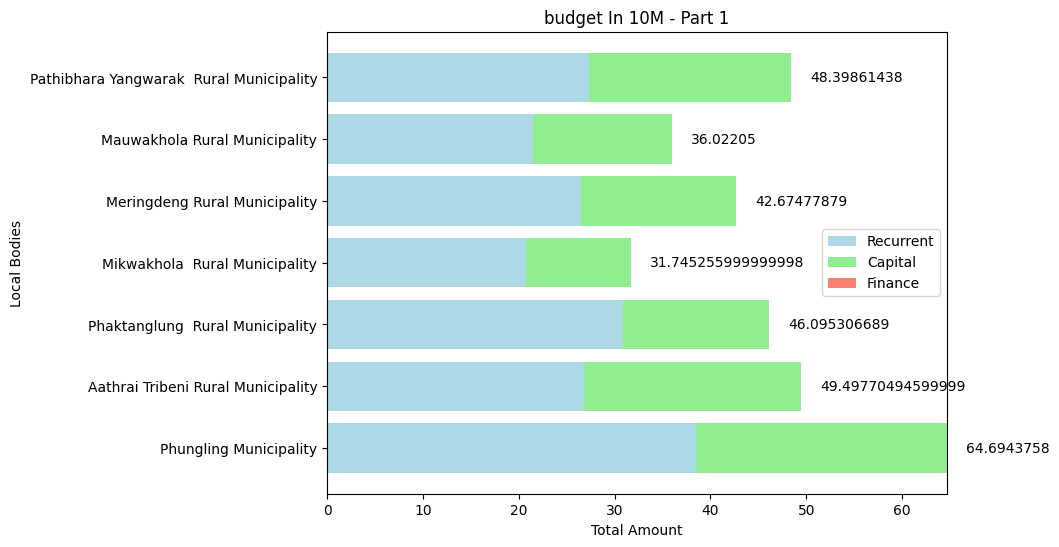

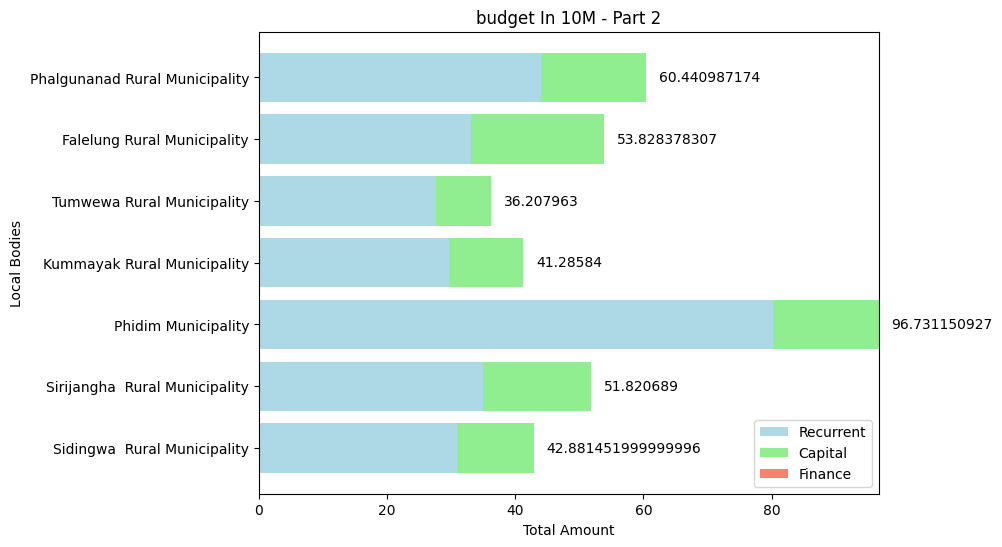

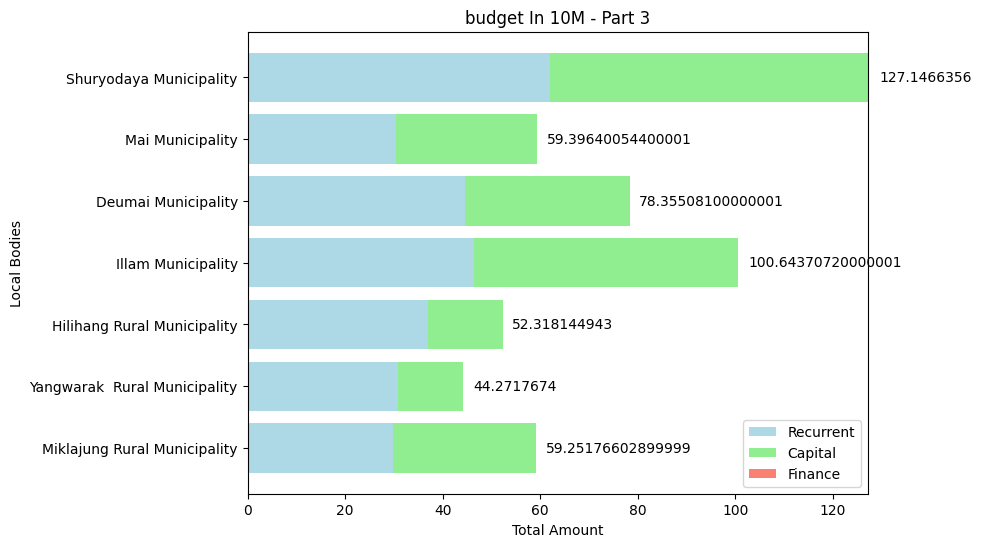

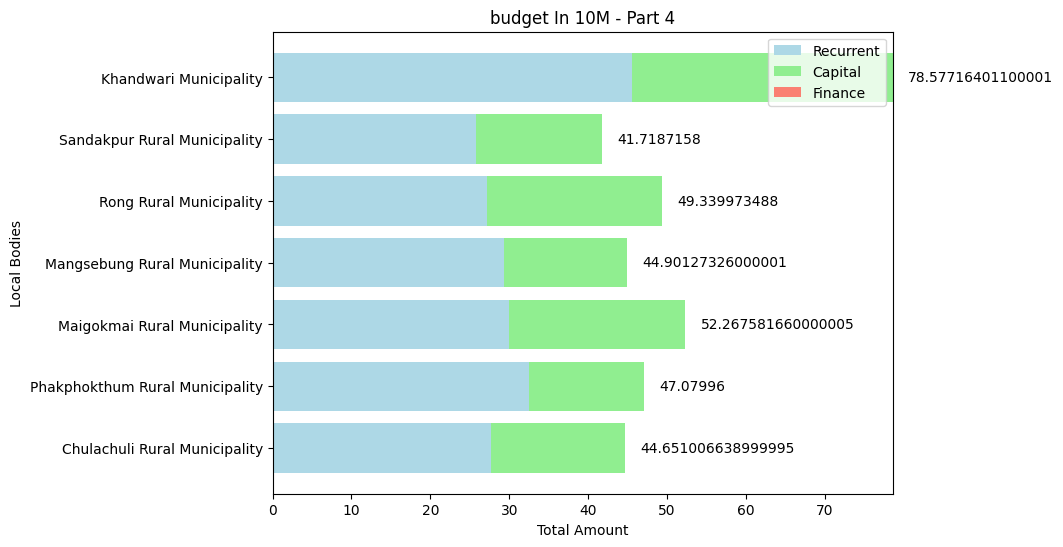

In [14]:
composition_analysis = CompositionAnalysis(dataframe=budget_df_province1, title="budget", total_attributes_limit=28, bar_limit=7)
# total_attributes_limit can be adjusted 
# total_attributes_limit/bar_limit = number of images
composition_analysis.plot_composition_bar()

**Observation**: 
- The budget composition for Province 1 is dominated by Recurrent and Capital categories.


In [15]:
color_dict = {
            'Recurrent': '#d42a08',
            'Capital': '#08d427',
            'Financial': '#a808d4'
        }
# can be passed as argument 

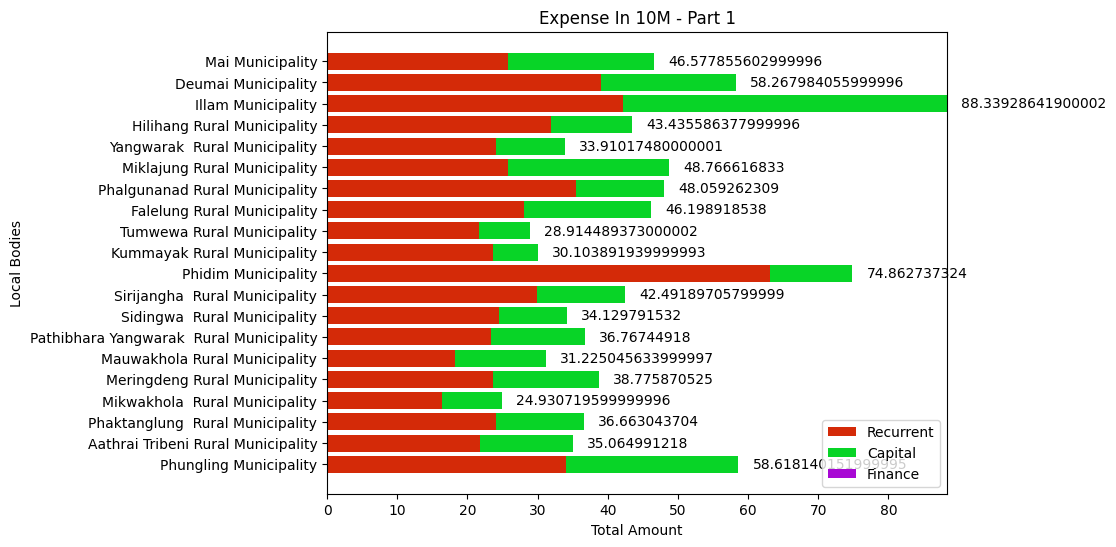

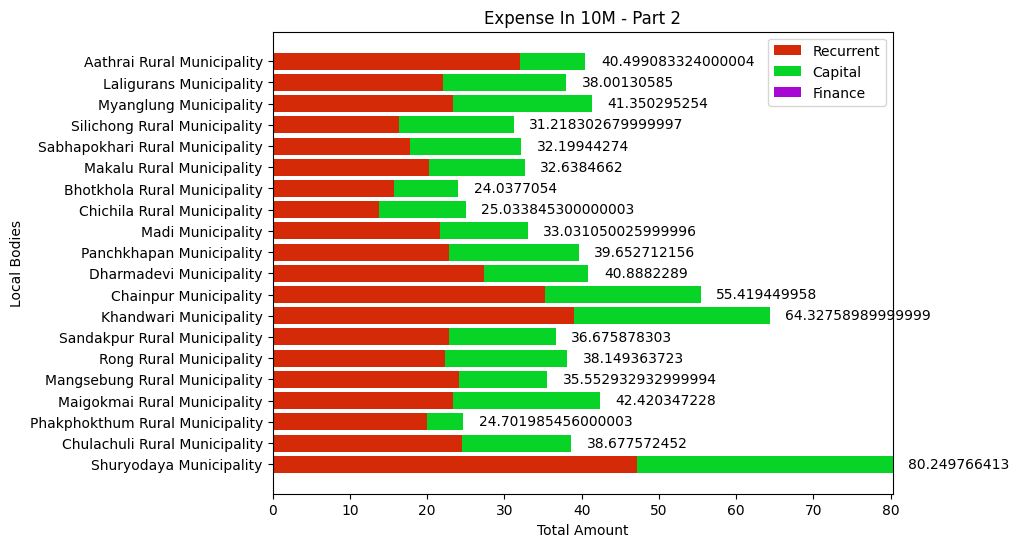

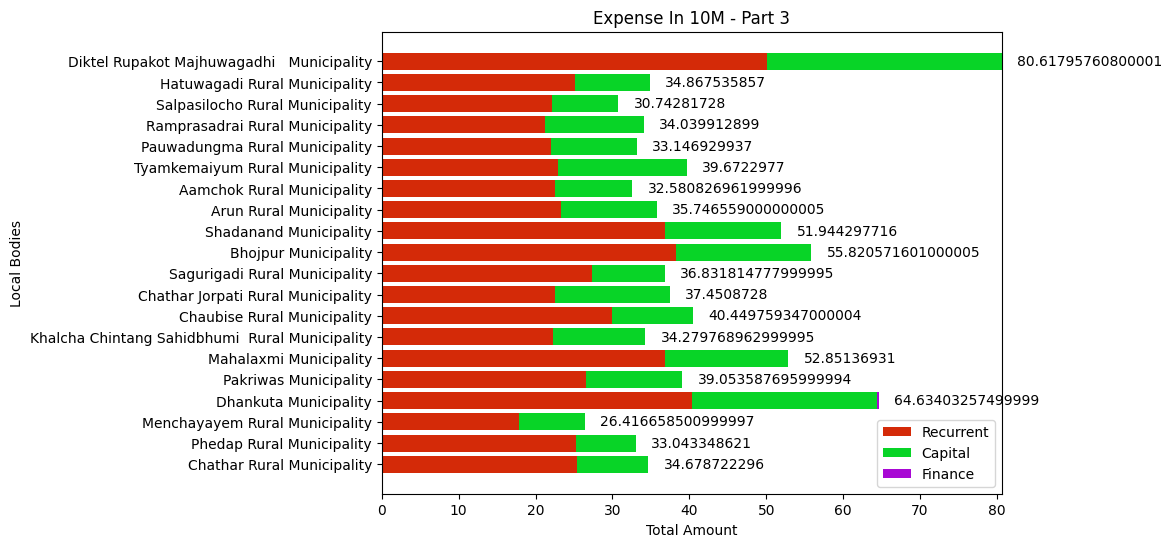

In [39]:
composition_analysis = CompositionAnalysis(dataframe=expense_df_province1, 
                                           title="Expense", 
                                           total_attributes_limit=60, 
                                           bar_colors=color_dict,
                                           bar_limit=20)
composition_analysis.plot_composition_bar()

**Observation**: 
- Expense composition shows Recurrent and Capital as the main components.

In [17]:
feature_extraction = FeatureExtraction(fname=file_path, province_name="Province 1")
budget_df, expense_df = feature_extraction.extract_individual()

Original data extracted successfully☺️
DataFrame Renamed successfully☺️
ALL THE OPERSTIONS WERE SUCCESSFUL😊


In [18]:
print(budget_df.shape)
budget_df.head()

(138, 7)


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,38.550184,26.144191,0.0,64.694376,7.666711
1,2,Aathrai Tribeni Rural Municipality,26.79269,22.705015,0.0,49.497705,12.857007
2,3,Phaktanglung Rural Municipality,30.862931,15.232376,0.0,46.095307,7.17987
3,4,Mikwakhola Rural Municipality,20.730677,11.014579,0.0,31.745256,6.718961
4,5,Meringdeng Rural Municipality,26.518959,16.155819,0.0,42.674779,2.881517


/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.dataframe_expense['Utilization_Rate'] = self.dataframe_expense['Utilization_Rate'].fillna(0)
/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


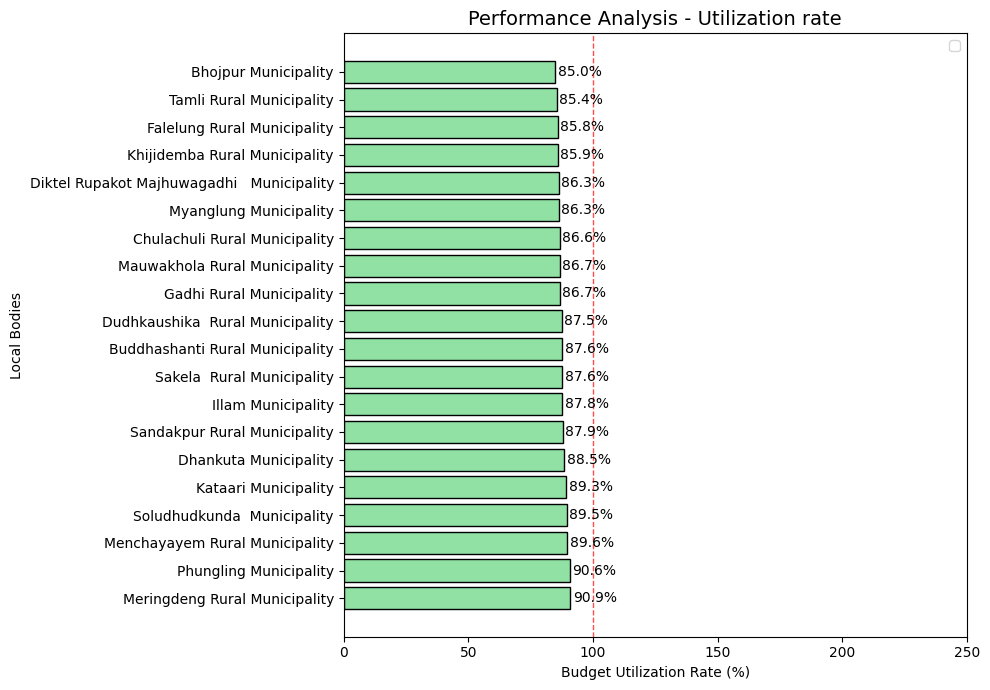

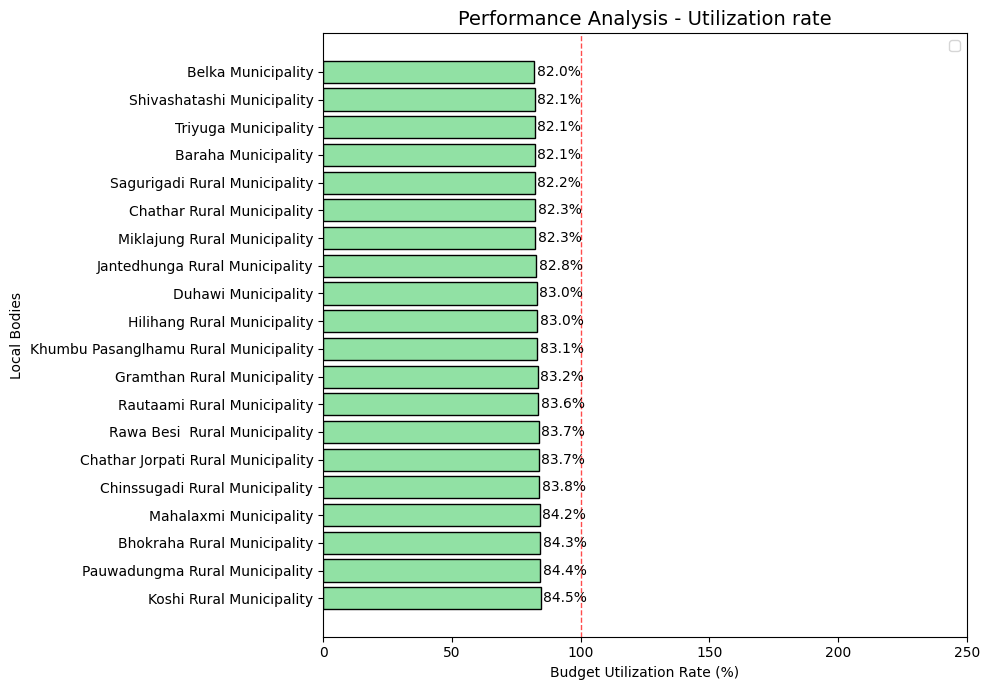

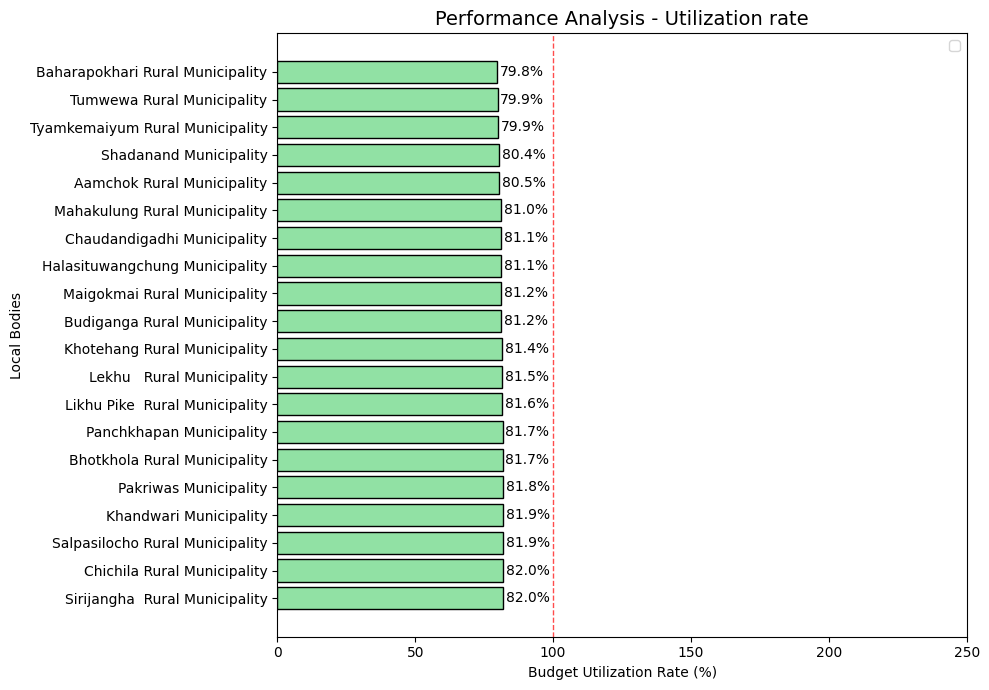

In [37]:
performance_analysis = PerformanceAnalysis(dataframe_budget=budget_df,
                                           dataframe_expense=expense_df,
                                           bar_limit=20,
                                           total_attributes_limit=60)
performance_analysis.plot_utilization_bar()

**Observation**: 
- The utilization bar shows local-level utilization.
- From this, it is hard to conclude overall utilization rate for Koshi province
- See utilization bar for provincial level

In [25]:
rename_dict = {"Province" : "Local Body"}
# Renamed just to match PerformanceAnalysis class argument
budget_df_total_renamed = budget_df_total.rename(columns=rename_dict).copy()
expense_df_total_renamed = expense_df_total.rename(columns=rename_dict)
budget_df_total_renamed.head()

,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
137,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
275,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
396,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
483,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
594,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353


/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.dataframe_expense['Utilization_Rate'] = self.dataframe_expense['Utilization_Rate'].fillna(0)
/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


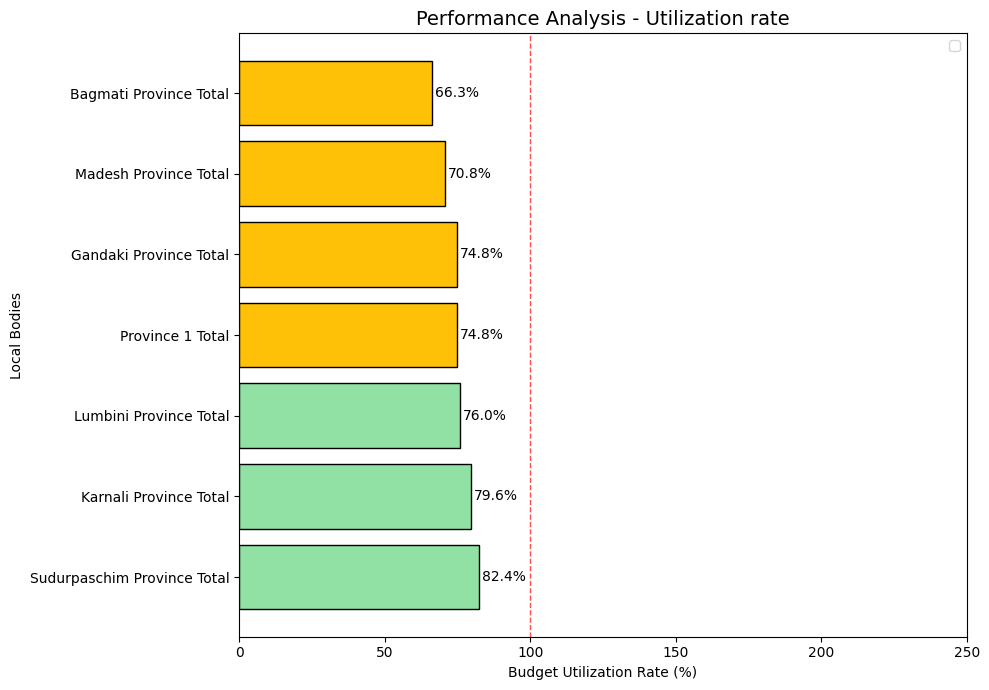

In [26]:
performance_analysis = PerformanceAnalysis(dataframe_budget=budget_df_total_renamed,
                                           dataframe_expense=expense_df_total_renamed,
                                           bar_limit=7,
                                           total_attributes_limit=7)
performance_analysis.plot_utilization_bar()

**Observation**:
- Koshi province uses 74.8% of it's total budget

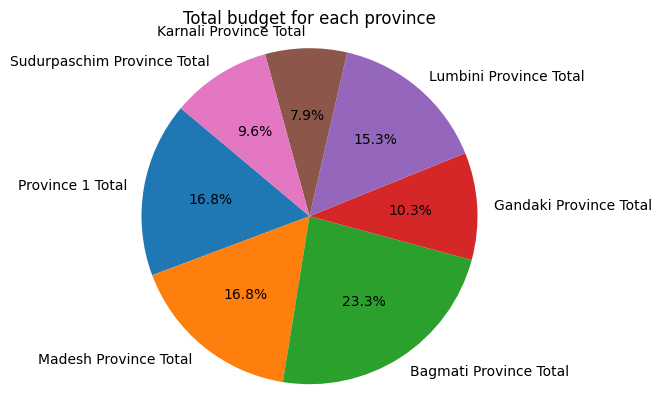

In [29]:
pie_charts = PieCharts(expense_frame=expense_df_province1,
                       budget_frame=budget_df_province1,
                       expense_total=expense_df_total,
                       budget_total=budget_df_total)
pie_charts.plot_for_total()

**Observation**: 
- Province-level pie chart shows that Koshi Province gets 16.8% of total budget.
- Which is second largest (as seen before).

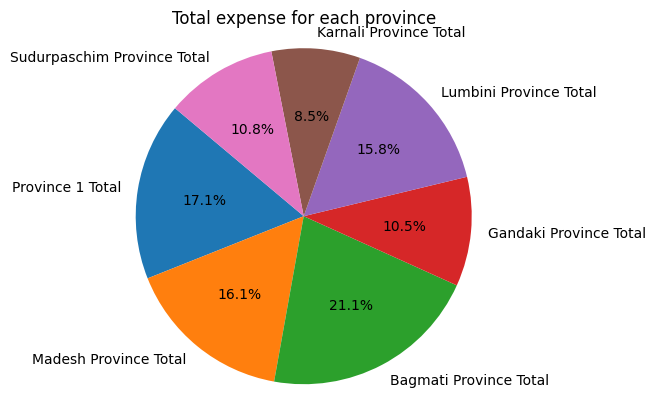

In [30]:
# For expense 
pie_charts.plot_for_total(type='expense')

**Observation**: 
- The Province-level expense pie reinforces that Koshi Province utilizes 17.1% of total utilization.

In [34]:
feature_extraction_urban = FeatureExtractionUrban(df=expense_df_all) # for all 753 local bodies
expense_df_urban_all = feature_extraction_urban.extract_urban_features().copy()
rows, column = expense_df_all.shape
print("Number of rows : ", rows)
expense_df_urban_all.head(rows)

Number of rows :  767


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
385,382,Kathmandu Metropolitan,354.66311,207.934436,8.5,571.097545,983.660309
427,422,Pokhara Metropolitan,215.258805,153.555389,0.0,368.814193,135.404153
358,355,Bharatpur Metropolitan,147.603064,171.580025,0.0,319.183088,163.427313
379,376,Lalitpur Metropolitan,111.677921,175.020062,0.0,286.697984,181.757992
261,260,Birjung Metropolitan,126.035539,84.956164,0.0,210.991703,51.231338
108,109,Biratnagar Metropolitan,106.329656,86.189002,4.30181,196.820467,46.12698
365,362,Hetauda Sub-Metropolitan,99.378983,83.797145,0.568287,183.744414,105.282164
568,561,Ghorahi Sub-Metropolitan,107.282697,73.116797,0.0,180.399494,33.644931
492,485,Butwal Sub-Metropolitan,71.628195,89.645037,0.6,161.873231,68.785717
569,562,Tulsipur Sub-Metropolitan,95.868249,60.524575,0.483074,156.875898,25.431784


/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.dataframe_expense['Utilization_Rate'] = self.dataframe_expense['Utilization_Rate'].fillna(0)
/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


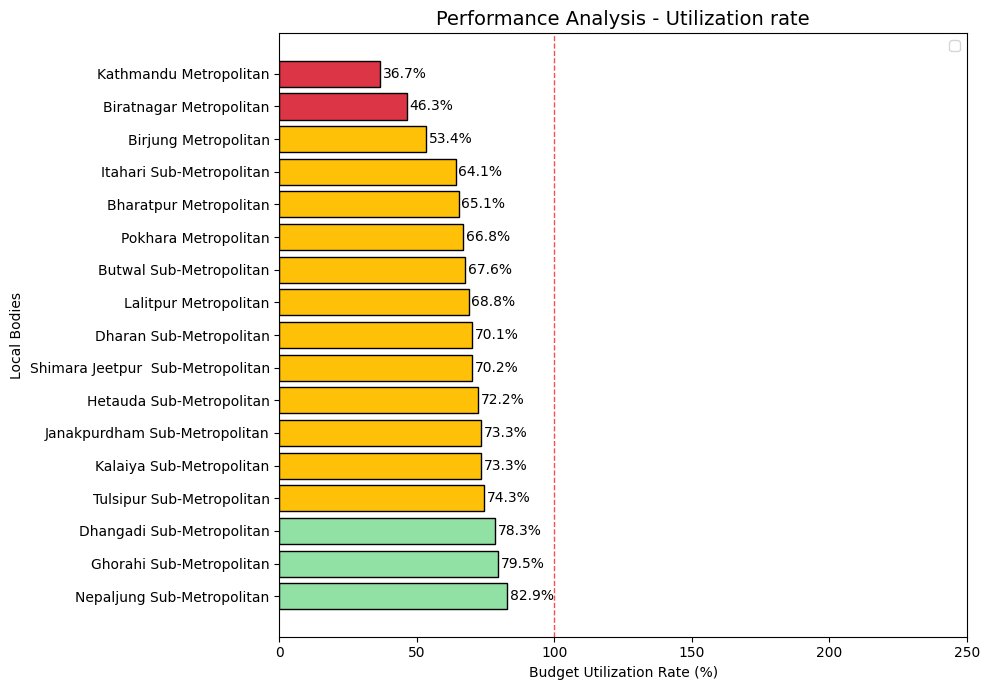

In [36]:
performance_analysis = PerformanceAnalysis(dataframe_budget=budget_df_urban_all,
                                           dataframe_expense=expense_df_urban_all,
                                           bar_limit=17,
                                           total_attributes_limit=17)
performance_analysis.plot_utilization_bar()

**Observation**:
- This shows urban level utilization bar.

**Conclusion**:
- Rank of Koshi on budget : 2
- Rank of koshi on expense : 2
- Utilization on Province-level : Rank(4), Percentage(74.8)
---
*Utilization on local-level*:
- Biratnagar Metropolitan: 46.3%
- Dharan Sub-Metropolitan: 70.1%
- Itahari Sub-Metropolitan: 64.1%
